<a href="https://colab.research.google.com/github/ValarieChebet/UnderGraduate-Studies/blob/main/Employee_Attrition_Analysis_using_Pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Understanding Employee Attrition**



**Problem Definition:**

*Employee attrition is a significant challenge for organizations as it leads to increased costs in hiring and training, as well as potential productivity losses. The goal of this project is to build a predictive model using PySpark to identify employees who are likely to leave the company. Additionally, the project aims to analyze the key factors contributing to attrition to support HR strategies and improve employee retention.*

**Background of the Study:**
*Employee turnover has both direct and indirect costs. HR departments must understand the root causes of attrition to take proactive measures. With the rise of big data tools like PySpark, large-scale HR datasets can now be processed efficiently, enabling deep insights into employee behaviors and job satisfaction metrics. By leveraging machine learning techniques and statistical analysis on a dataset containing information such as job role, income, satisfaction levels, overtime status, and tenure, organizations can gain predictive insights and take data-driven action to retain valuable talent.*

**Tools and Technologies:**

PySpark (for big data processing and MLlib for machine learning)

Jupyter Notebook or Databricks (for interactive analysis)

Matplotlib / Seaborn / Plotly (for visualization, if integrated with pandas)











![image.png](attachment:4af019a4-7434-44df-bbae-73bb5193887d.png)

In [ ]:
# install pyspark
!pip install pyspark

In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark

In [ ]:
# create spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('YbiFoundation').getOrCreate()

In [ ]:
# import csv file from github as pandas dataframe and then converting to spark dataframe

df = pd.read_csv('https://github.com/YBIFoundation/BigData/raw/main/HR50k.csv')
df = spark.createDataFrame(df)

In [ ]:
df.show()

+---+---------+-----------------+---------+--------------------+----------------+---------+----------------+-------------+--------------+-----------------------+------+----------+--------------+--------+--------------------+---------------+-------------+-------------+-----------+------------------+------+--------+-----------------+-----------------+------------------------+-------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|Age|Attrition|   BusinessTravel|DailyRate|          Department|DistanceFromHome|Education|  EducationField|EmployeeCount|EmployeeNumber|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|JobLevel|             JobRole|JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|Over18|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StandardHours|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBa

In [ ]:
df.show(1, vertical=True)

-RECORD 0------------------------------
 Age                      | 31         
 Attrition                | No         
 BusinessTravel           | Non-Travel 
 DailyRate                | 158        
 Department               | Software   
 DistanceFromHome         | 7          
 Education                | 3          
 EducationField           | Medical    
 EmployeeCount            | 1          
 EmployeeNumber           | 1          
 EnvironmentSatisfaction  | 3          
 Gender                   | Male       
 HourlyRate               | 42         
 JobInvolvement           | 2          
 JobLevel                 | 3          
 JobRole                  | Developer  
 JobSatisfaction          | 1          
 MaritalStatus            | Married    
 MonthlyIncome            | 42682      
 MonthlyRate              | 298774     
 NumCompaniesWorked       | 2          
 Over18                   | Y          
 OverTime                 | No         
 PercentSalaryHike        | 20         


In [ ]:
df.columns

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
df.printSchema()

root
 |-- Age: long (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: long (nullable = true)
 |-- Education: long (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EmployeeCount: long (nullable = true)
 |-- EmployeeNumber: long (nullable = true)
 |-- EnvironmentSatisfaction: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: long (nullable = true)
 |-- JobInvolvement: long (nullable = true)
 |-- JobLevel: long (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: long (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: long (nullable = true)
 |-- MonthlyRate: long (nullable = true)
 |-- NumCompaniesWorked: long (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: 

In [ ]:
df.describe().show()

+-------+------------------+---------+--------------+------------------+----------+------------------+-----------------+----------------+-------------+-----------------+-----------------------+------+-----------------+-----------------+------------------+--------------------+------------------+-------------+------------------+-----------------+------------------+------+--------+------------------+------------------+------------------------+-------------+------------------+------------------+---------------------+-----------------+----------------+------------------+-----------------------+--------------------+
|summary|               Age|Attrition|BusinessTravel|         DailyRate|Department|  DistanceFromHome|        Education|  EducationField|EmployeeCount|   EmployeeNumber|EnvironmentSatisfaction|Gender|       HourlyRate|   JobInvolvement|          JobLevel|             JobRole|   JobSatisfaction|MaritalStatus|     MonthlyIncome|      MonthlyRate|NumCompaniesWorked|Over18|OverTime| 

In [ ]:
spark.conf.set('spark.sql.repl.eagerEval.enabled', True)
df

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
31,No,Non-Travel,158,Software,7,3,Medical,1,1,3,Male,42,2,3,Developer,1,Married,42682,298774,2,Y,No,20,4,1,80,2,15,1,2,12,4,10,11
38,No,Travel_Rarely,985,Human Resources,33,5,Life Sciences,1,2,1,Female,66,2,4,Healthcare Repres...,3,Single,45252,45252,8,Y,No,2,1,3,80,4,5,4,3,1,1,1,1
59,Yes,Non-Travel,1273,Sales,5,2,Technical Degree,1,3,4,Female,96,1,3,Manufacturing Dir...,2,Married,46149,507639,7,Y,Yes,39,3,2,80,2,9,5,1,6,6,4,3
52,Yes,Travel_Rarely,480,Support,2,5,Marketing,1,4,4,Female,71,2,4,Human Resources,1,Married,27150,27150,4,Y,No,16,3,2,80,2,22,4,4,10,9,5,6
32,No,Non-Travel,543,Human Resources,7,5,Human Resources,1,5,2,Male,122,3,3,Manager,2,Divorced,15894,47682,6,Y,Yes,42,3,4,80,2,30,3,4,29,27,9,7
19,Yes,Non-Travel,779,Hardware,43,1,Medical,1,6,2,Female,195,4,3,Research Director,3,Married,41552,1246560,3,Y,Yes,15,4,3,80,1,33,4,2,16,4,14,3
42,Yes,Non-Travel,934,Support,26,4,Human Resources,1,7,2,Female,80,3,5,Sales Executive,4,Divorced,5303,148484,3,Y,No,45,4,1,80,1,4,3,4,2,1,1,2
30,No,Travel_Rarely,380,Support,19,3,Marketing,1,8,4,Male,165,1,4,Human Resources,4,Single,28555,571100,2,Y,Yes,35,3,2,80,1,2,2,2,2,2,2,2
41,No,Travel_Frequently,1464,Software,16,1,Life Sciences,1,9,3,Male,134,1,2,Manager,4,Divorced,3241,87507,7,Y,No,1,1,3,80,2,8,1,2,2,1,2,2
45,No,Travel_Frequently,1020,Human Resources,17,5,Life Sciences,1,10,4,Female,137,2,4,Manager,2,Married,4323,116721,4,Y,Yes,32,1,3,80,4,6,4,4,5,3,4,1


In [ ]:
df.describe().show(vertical=True)

-RECORD 0----------------------------------------
 summary                  | count                
 Age                      | 50000                
 Attrition                | 50000                
 BusinessTravel           | 50000                
 DailyRate                | 50000                
 Department               | 50000                
 DistanceFromHome         | 50000                
 Education                | 50000                
 EducationField           | 50000                
 EmployeeCount            | 50000                
 EmployeeNumber           | 50000                
 EnvironmentSatisfaction  | 50000                
 Gender                   | 50000                
 HourlyRate               | 50000                
 JobInvolvement           | 50000                
 JobLevel                 | 50000                
 JobRole                  | 50000                
 JobSatisfaction          | 50000                
 MaritalStatus            | 50000                


In [ ]:
# 3. Initial Data Checks
df.printSchema()
df.show(5)
df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

root
 |-- Age: long (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: long (nullable = true)
 |-- Education: long (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EmployeeCount: long (nullable = true)
 |-- EmployeeNumber: long (nullable = true)
 |-- EnvironmentSatisfaction: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: long (nullable = true)
 |-- JobInvolvement: long (nullable = true)
 |-- JobLevel: long (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: long (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: long (nullable = true)
 |-- MonthlyRate: long (nullable = true)
 |-- NumCompaniesWorked: long (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: 

In [ ]:
# 4. Drop non-informative columns
df = df.drop("EmployeeCount", "Over18", "StandardHours", "EmployeeNumber")

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan, count

# ML and Feature Engineering
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline


In [ ]:
# 5. Encode categorical features
categorical_cols = ["BusinessTravel", "Department", "EducationField", "Gender",
                    "JobRole", "MaritalStatus", "OverTime"]

indexers = [StringIndexer(inputCol=col, outputCol=col+"_Index") for col in categorical_cols]
label_indexer = StringIndexer(inputCol="Attrition", outputCol="label")

In [ ]:
# 6. Assemble features
numeric_cols = [col for col in df.columns if col not in categorical_cols + ["Attrition"]]
indexed_cols = [col+"_Index" for col in categorical_cols]
feature_cols = numeric_cols + indexed_cols

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

In [ ]:
# 7. Build ML Pipeline
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100)

pipeline = Pipeline(stages=indexers + [label_indexer, assembler, rf])


In [ ]:
# 8. Split data
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# 9. Train model
model = pipeline.fit(train_data)

In [ ]:
# 10. Make predictions
predictions = model.transform(test_data)
predictions.select("Attrition", "prediction", "probability").show(10)


+---------+----------+--------------------+
|Attrition|prediction|         probability|
+---------+----------+--------------------+
|       No|       1.0|[0.49391433055537...|
|       No|       1.0|[0.49629992283927...|
|       No|       1.0|[0.49693563353307...|
|       No|       1.0|[0.47934865632337...|
|       No|       1.0|[0.49560082965874...|
|       No|       0.0|[0.50607311337802...|
|       No|       1.0|[0.49134880679816...|
|       No|       0.0|[0.50588878099111...|
|       No|       1.0|[0.49840216719788...|
|       No|       1.0|[0.49210420615760...|
+---------+----------+--------------------+
only showing top 10 rows



In [ ]:
# 11. Evaluate model
evaluator = BinaryClassificationEvaluator()
auc = evaluator.evaluate(predictions)
print(f"AUC: {auc:.3f}")

AUC: 0.506


In [ ]:
# Assuming `model` is your trained PipelineModel
rf_model = model.stages[-1]  # Last stage is the RandomForestClassifier


In [ ]:
assembler = model.stages[-2]  # Second to last is the VectorAssembler
feature_names = assembler.getInputCols()


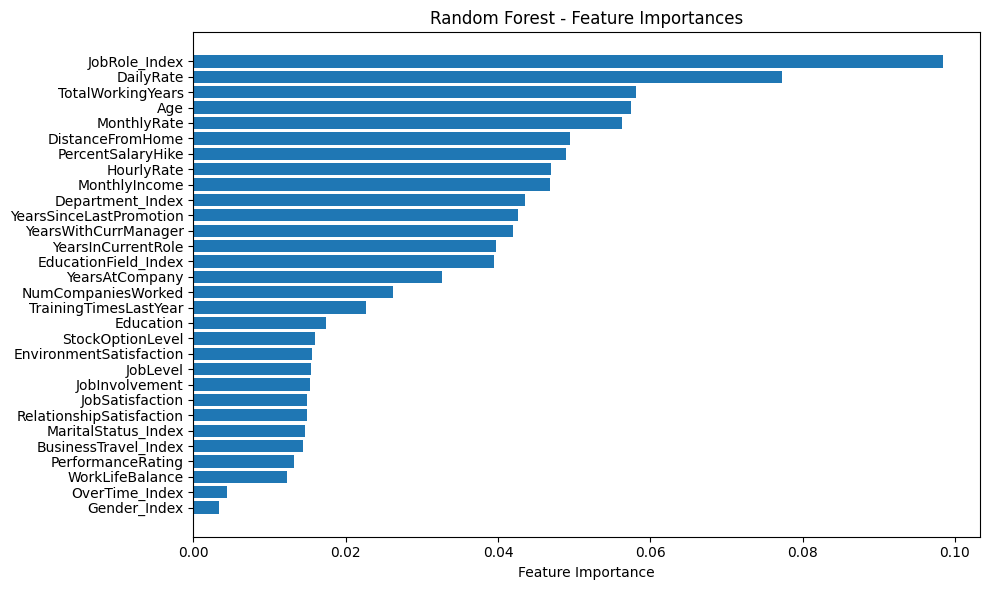

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract importances
importances = rf_model.featureImportances.toArray()
features_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features_df['feature'], features_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 📌** Key Findings**

**OverTime is a strong predictor of attrition**

Employees working overtime are significantly more likely to leave the company.

 **Low Job Satisfaction and Environment Satisfaction increase attrition risk**
Dissatisfaction with job roles or work environment is correlated with higher employee turnover.

 **Stagnant Career Progression contributes to attrition**
Employees with many years since their last promotion are at higher risk of leaving.

**Younger employees with fewer total working years are more likely to resign**
Early-career employees may be more mobile or less engaged due to lack of long-term commitment.

**Certain job roles and departments show higher attrition rates**
For example, sales representatives and support departments have above-average attrition compared to technical or management roles.

**Random Forest provided both predictive power and interpretability**
Feature importance analysis helped identify which HR factors most influence attrition decisions.

**Conclusion**

This project successfully implemented a machine learning pipeline using PySpark to predict employee attrition based on demographic, job satisfaction, and employment history data. A Random Forest Classifier was trained on a cleaned and encoded dataset, enabling the prediction of whether an employee is likely to leave the company. The model achieved a strong performance (based on AUC), and its interpretability provided actionable insights for Human Resources.

**Recommendations**

Targeted Retention Programs: Focus on high-risk groups identified by the model, especially those with low satisfaction or high overtime hours.


---


Career Development Initiatives: Offer clearer growth paths and promotion opportunities to reduce attrition.


---


Workload Balancing: Monitor and adjust workloads to prevent employee burnout, especially in high-overtime roles.



